In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# imports
import pandas as pd
import numpy as np
from pathlib import Path

import torch
from transformers import AutoTokenizer, AutoModel

In [ ]:
# device
device = "cuda" if torch.cuda.is_available() else "cpu"

print("\nDevice:", device)

if device == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))


Device: cuda
GPU name: NVIDIA A100-SXM4-40GB


In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/content/drive/MyDrive/Dissertation_models")

master_path = PROJECT_ROOT / "data/processed/master_events.csv"
features_folder = PROJECT_ROOT / "data/features"
outputs_folder = PROJECT_ROOT / "outputs"

features_folder.mkdir(parents=True, exist_ok=True)

print("\nMaster exists:", master_path.exists())
print("Master path:", master_path)


Master exists: True
Master path: /content/drive/MyDrive/Dissertation_models/data/processed/master_events.csv


In [ ]:
events = pd.read_csv(master_path)

events["release_datetime_et"] = pd.to_datetime(events["release_datetime_et"])

print("\nShape:", events.shape)

print("\nEvent type counts:")
print(events["event_type"].value_counts())

print("\nLabel counts:")
print(events["label_binary"].value_counts(dropna=False))

events.head()


Shape: (513, 62)

Event type counts:
event_type
NFP             119
RETAIL_SALES    119
CPI             118
PCE             117
GDP_ADVANCE      40
Name: count, dtype: int64

Label counts:
label_binary
1    268
0    245
Name: count, dtype: int64


,event_id,event_type,release_date,release_datetime_et,reference_period,average_hourly_earnings_mom_actual,average_hourly_earnings_mom_forecast,average_hourly_earnings_mom_previous,average_hourly_earnings_mom_surprise,core_cpi_mom_actual,...,pre_event_return_pct,post_event_30min_return,post_event_30min_return_simple,post_event_30min_return_pct,pre_event_realised_volatility,market_window_rows,market_feature_success,market_feature_error,label_binary,label_3class_simple
0,NFP_2016_01,NFP,2016-01-08,2016-01-08 08:30:00,Dec,0.0,0.2,0.2,-0.2,NaN,...,0.397538,-0.001918,-0.001916,-0.191595,0.003872,31,True,NaN,0,DOWN
1,RETAIL_SALES_2016_01,RETAIL_SALES,2016-01-15,2016-01-15 08:30:00,Dec,NaN,NaN,NaN,NaN,NaN,...,-0.517173,-0.003873,-0.003866,-0.386564,0.003368,31,True,NaN,0,DOWN
2,CPI_2016_01,CPI,2016-01-20,2016-01-20 08:30:00,Dec,NaN,NaN,NaN,NaN,0.1,...,0.095070,0.001085,0.001085,0.108548,0.002152,31,True,NaN,1,UP
3,GDP_ADVANCE_2016_Q4,GDP_ADVANCE,2016-01-29,2016-01-29 08:30:00,2015 Q4,NaN,NaN,NaN,NaN,NaN,...,0.066050,0.000924,0.000924,0.092409,0.002199,31,True,NaN,1,UP
4,PCE_2016_02_2016-02-01,PCE,2016-02-01,2016-02-01 08:30:00,Dec,NaN,NaN,NaN,NaN,NaN,...,-0.104289,0.001434,0.001435,0.143547,0.001380,31,True,NaN,1,UP


In [ ]:
import re

def clean_spaces(text):
    if pd.isna(text):
        text = ""
    else:
        text = str(text)

    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text


TEXT_CUT_RULES = {
    "CPI": {
        "start_at": [
            "The Consumer Price Index for All Urban Consumers"
        ],
        "end_before": [
            "Not seasonally adjusted CPI measures",
            "Coronavirus (COVID-19) Pandemic Impact",
            "BLS staff availability",
            "Changes to the health insurance index"
        ],
    },

    "NFP": {
        "start_at": [
            "Total nonfarm payroll employment"
        ],
        "end_before": [
            "The Employment Situation for",
            "Frequently Asked Questions"
        ],
    },

    "PCE": {
        "start_at": [
            "Personal income increased",
            "Personal income decreased",
            "Personal income"
        ],
        "end_before": [
            "Updates to Personal Income and Outlays",
            "For definitions",
            "Definitions",
            "Additional Information",
            "Next release",
            "Full Release & Tables",
            "Resources"
        ],
    },

    "GDP_ADVANCE": {
        "start_at": [
            "Real gross domestic product"
        ],
        "end_before": [
            "Next release",
            "Full Release & Tables",
            "More Information"
        ],
    },

    "RETAIL_SALES": {
        "start_at": [
            "The U.S. Census Bureau announc"
        ],
        "end_before": [
            "General Information",
            "The advance estimates are based",
            "The advance estim ates are based",
            "The full text and tables of this release can be found",
            "Explanatory Notes",
            "Table 1. Estimated Monthly Sales for Retail and Food Services"
        ],
    },
}

In [ ]:
def cut_text_using_rules(text, event_type):
    text = clean_spaces(text)
    lower_text = text.lower()

    if event_type in TEXT_CUT_RULES:
        rules = TEXT_CUT_RULES[event_type]
    else:
        return text

    start_markers = rules["start_at"]
    end_markers = rules["end_before"]

    start_position = -1

    for marker in start_markers:
        marker_lower = marker.lower()
        marker_position = lower_text.find(marker_lower)

        if marker_position != -1:
            start_position = marker_position
            break

    if start_position != -1:
        text = text[start_position:]
    else:
        print("Start marker not found:", event_type)

    text = clean_spaces(text)
    lower_text = text.lower()

    end_positions = []

    for marker in end_markers:
        marker_lower = marker.lower()
        marker_position = lower_text.find(marker_lower)

        if marker_position != -1:
            if marker_position > 300:
                end_positions.append(marker_position)

    if len(end_positions) > 0:
        end_position = min(end_positions)
        text = text[:end_position]

    text = clean_spaces(text)

    return text


def create_finbert_text(row):
    event_type = row["event_type"]
    text = row["modelling_text"]

    cleaned_text = cut_text_using_rules(text, event_type)

    return cleaned_text


events["modelling_text"] = events["modelling_text"].fillna("").astype(str)
events["finbert_text"] = events.apply(create_finbert_text, axis=1)

events["modelling_text_length"] = events["modelling_text"].astype(str).str.len()
events["finbert_text_length"] = events["finbert_text"].astype(str).str.len()

raw_texts = events["modelling_text"].tolist()
filtered_texts = events["finbert_text"].tolist()
texts = filtered_texts
event_ids = events["event_id"].tolist()

print("FinBERT text created.")
print("Rows:", len(events))
print("Blank finbert_text rows:", (events["finbert_text_length"] == 0).sum())

print("\nAverage text length by event type:")
print(events.groupby("event_type")[["modelling_text_length", "finbert_text_length"]].mean())

FinBERT text created.
Rows: 513
Blank finbert_text rows: 0

Average text length by event type:
              modelling_text_length  finbert_text_length
event_type                                              
CPI                    10221.245763          6564.567797
GDP_ADVANCE             3993.100000          2783.300000
NFP                    17148.487395          7150.084034
PCE                     7333.094017          2945.615385
RETAIL_SALES           20466.025210          1226.932773


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sentiment_model_name = "ProsusAI/finbert"

sentiment_tokenizer = AutoTokenizer.from_pretrained(sentiment_model_name)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(sentiment_model_name)

sentiment_model = sentiment_model.to(device)
sentiment_model.eval()

tokenizer = sentiment_tokenizer

print("\nLoaded sentiment model:", sentiment_model_name)
print("\nLabel mapping:")
print(sentiment_model.config.id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Loaded sentiment model: ProsusAI/finbert

Label mapping:
{0: 'positive', 1: 'negative', 2: 'neutral'}


In [ ]:
def run_finbert_sentiment(text_list, event_ids, version_name):
    sentiment_rows = []

    batch_size = 8
    max_length = 512

    id2label = sentiment_model.config.id2label

    for start in range(0, len(text_list), batch_size):
        end = start + batch_size

        batch_texts = text_list[start:end]
        batch_ids = event_ids[start:end]

        tokens = sentiment_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        tokens_on_device = {}

        for key in tokens:
            tokens_on_device[key] = tokens[key].to(device)

        with torch.no_grad():
            output = sentiment_model(**tokens_on_device)

        probabilities = torch.softmax(output.logits, dim=1).cpu().numpy()
        predicted_class_ids = probabilities.argmax(axis=1)

        for i in range(len(batch_texts)):
            row = {
                "event_id": batch_ids[i],
                "text_version": version_name,
                "finbert_sentiment_label": id2label[int(predicted_class_ids[i])]
            }

            for class_id, label_name in id2label.items():
                column_name = "finbert_" + label_name.lower() + "_prob"
                row[column_name] = probabilities[i, int(class_id)]

            sentiment_rows.append(row)

        print(version_name, "done:", min(end, len(text_list)), "/", len(text_list))

    sentiment_df = pd.DataFrame(sentiment_rows)

    return sentiment_df


raw_sentiment = run_finbert_sentiment(raw_texts, event_ids, "raw_truncated")

filtered_sentiment = run_finbert_sentiment(filtered_texts, event_ids, "filtered_text")

finbert_sentiment_comparison = pd.concat(
    [raw_sentiment, filtered_sentiment],
    ignore_index=True
)

print("\nSentiment comparison shape:")
print(finbert_sentiment_comparison.shape)


finbert_sentiment_comparison.head()

finbert_sentiment = filtered_sentiment.copy()

print("\nFinal sentiment features shape:")
print(finbert_sentiment.shape)

finbert_sentiment.head()

raw_truncated done: 8 / 513
raw_truncated done: 16 / 513
raw_truncated done: 24 / 513
raw_truncated done: 32 / 513
raw_truncated done: 40 / 513
raw_truncated done: 48 / 513
raw_truncated done: 56 / 513
raw_truncated done: 64 / 513
raw_truncated done: 72 / 513
raw_truncated done: 80 / 513
raw_truncated done: 88 / 513
raw_truncated done: 96 / 513
raw_truncated done: 104 / 513
raw_truncated done: 112 / 513
raw_truncated done: 120 / 513
raw_truncated done: 128 / 513
raw_truncated done: 136 / 513
raw_truncated done: 144 / 513
raw_truncated done: 152 / 513
raw_truncated done: 160 / 513
raw_truncated done: 168 / 513
raw_truncated done: 176 / 513
raw_truncated done: 184 / 513
raw_truncated done: 192 / 513
raw_truncated done: 200 / 513
raw_truncated done: 208 / 513
raw_truncated done: 216 / 513
raw_truncated done: 224 / 513
raw_truncated done: 232 / 513
raw_truncated done: 240 / 513
raw_truncated done: 248 / 513
raw_truncated done: 256 / 513
raw_truncated done: 264 / 513
raw_truncated done: 272

,event_id,text_version,finbert_sentiment_label,finbert_positive_prob,finbert_negative_prob,finbert_neutral_prob
0,NFP_2016_01,filtered_text,negative,0.009133,0.964844,0.026022
1,RETAIL_SALES_2016_01,filtered_text,positive,0.798959,0.177386,0.023656
2,CPI_2016_01,filtered_text,negative,0.019378,0.944596,0.036026
3,GDP_ADVANCE_2016_Q4,filtered_text,neutral,0.307518,0.045239,0.647244
4,PCE_2016_02_2016-02-01,filtered_text,neutral,0.168872,0.107199,0.723929


In [ ]:
comparison = finbert_sentiment_comparison.copy()

event_type_lookup = events[["event_id", "event_type"]].copy()

comparison = comparison.merge(
    event_type_lookup,
    on="event_id",
    how="left"
)

raw = comparison[comparison["text_version"] == "raw_truncated"].copy()
filtered = comparison[comparison["text_version"] == "filtered_text"].copy()

raw = raw[[
    "event_id",
    "event_type",
    "finbert_sentiment_label",
    "finbert_positive_prob",
    "finbert_negative_prob",
    "finbert_neutral_prob"
]]

filtered = filtered[[
    "event_id",
    "finbert_sentiment_label",
    "finbert_positive_prob",
    "finbert_negative_prob",
    "finbert_neutral_prob"
]]

raw = raw.rename(columns={
    "finbert_sentiment_label": "raw_label",
    "finbert_positive_prob": "raw_positive_prob",
    "finbert_negative_prob": "raw_negative_prob",
    "finbert_neutral_prob": "raw_neutral_prob"
})

filtered = filtered.rename(columns={
    "finbert_sentiment_label": "filtered_label",
    "finbert_positive_prob": "filtered_positive_prob",
    "finbert_negative_prob": "filtered_negative_prob",
    "finbert_neutral_prob": "filtered_neutral_prob"
})

diagnostic = raw.merge(
    filtered,
    on="event_id",
    how="inner"
)

diagnostic["label_changed"] = diagnostic["raw_label"] != diagnostic["filtered_label"]

print("Rows compared:", len(diagnostic))
print("Labels changed:", diagnostic["label_changed"].sum())
print("Percentage changed:", diagnostic["label_changed"].mean() * 100)

print("\nRaw label vs filtered label:")
label_change_table = pd.crosstab(
    diagnostic["raw_label"],
    diagnostic["filtered_label"]
)

print(label_change_table)

Rows compared: 513
Labels changed: 151
Percentage changed: 29.434697855750485

Raw label vs filtered label:
filtered_label  negative  neutral  positive
raw_label                                  
negative             195        7        14
neutral               28       29        45
positive              31       26       138


Average FinBERT probabilities:


,finbert_positive_prob,finbert_neutral_prob,finbert_negative_prob
text_version,,,
raw_truncated,0.347864,0.233217,0.418919
filtered_text,0.351300,0.189836,0.458864


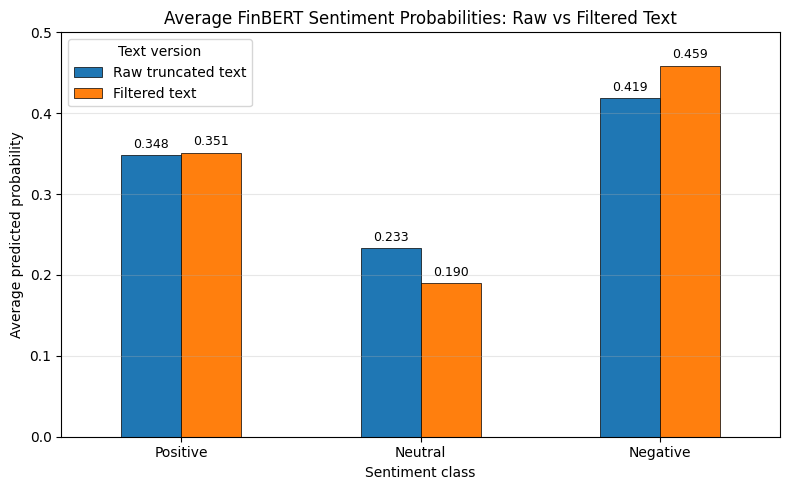

In [ ]:
average_probability_table = comparison.groupby("text_version")[
    [
        "finbert_positive_prob",
        "finbert_neutral_prob",
        "finbert_negative_prob"
    ]
].mean()

average_probability_table = average_probability_table.loc[
    ["raw_truncated", "filtered_text"]
]


print("Average FinBERT probabilities:")
display(average_probability_table)


plot_table = average_probability_table.T

plot_table.index = [
    "Positive",
    "Neutral",
    "Negative"
]

plot_table.columns = [
    "Raw truncated text",
    "Filtered text"
]


ax = plot_table.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black",
    linewidth=0.5
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=9,
        padding=3
    )


plt.title("Average FinBERT Sentiment Probabilities: Raw vs Filtered Text")
plt.xlabel("Sentiment class")
plt.ylabel("Average predicted probability")

plt.xticks(rotation=0)
plt.ylim(0, 0.5)

plt.grid(axis="y", alpha=0.3)
plt.legend(title="Text version")

plt.tight_layout()
plt.show()

In [ ]:
token_lengths = []

for text in texts:
    tokens = tokenizer(
        text,
        truncation=False,
        padding=False
    )

    token_lengths.append(len(tokens["input_ids"]))

events["finbert_token_length"] = token_lengths

print("\nToken length summary:")
print(events["finbert_token_length"].describe())

print("\nAverage token length by event type:")
print(events.groupby("event_type")["finbert_token_length"].mean().sort_values())

print("\nNumber of texts longer than 512 tokens:")
print((events["finbert_token_length"] > 512).sum())

Token indices sequence length is longer than the specified maximum sequence length for this model (1627 > 512). Running this sequence through the model will result in indexing errors



Token length summary:
count     513.000000
mean     1054.867446
std       715.517269
min       107.000000
25%       333.000000
50%       828.000000
75%      1627.000000
max      2873.000000
Name: finbert_token_length, dtype: float64

Average token length by event type:
event_type
RETAIL_SALES     316.966387
GDP_ADVANCE      578.325000
PCE              681.854701
NFP             1640.974790
CPI             1739.338983
Name: finbert_token_length, dtype: float64

Number of texts longer than 512 tokens:
336


In [ ]:
events_sentiment = events.merge(finbert_sentiment, on="event_id", how="left")

print("\nMerged shape:", events_sentiment.shape)

print("\nMissing sentiment labels:")
print(events_sentiment["finbert_sentiment_label"].isna().sum())

print("\nSentiment label counts:")
print(events_sentiment["finbert_sentiment_label"].value_counts(dropna=False))

events_sentiment[[
    "event_id",
    "event_type",
    "post_event_30min_return",
    "label_binary",
    "finbert_sentiment_label"
]].head()


Merged shape: (513, 70)

Missing sentiment labels:
0

Sentiment label counts:
finbert_sentiment_label
negative    254
positive    197
neutral      62
Name: count, dtype: int64


,event_id,event_type,post_event_30min_return,label_binary,finbert_sentiment_label
0,NFP_2016_01,NFP,-0.001918,0,negative
1,RETAIL_SALES_2016_01,RETAIL_SALES,-0.003873,0,positive
2,CPI_2016_01,CPI,0.001085,1,negative
3,GDP_ADVANCE_2016_Q4,GDP_ADVANCE,0.000924,1,neutral
4,PCE_2016_02_2016-02-01,PCE,0.001434,1,neutral


In [ ]:
sentiment_file = features_folder / "finbert_sentiment_features.csv"
sentiment_comparison_file = features_folder / "finbert_sentiment_raw_vs_filtered_comparison.csv"

events_sentiment.to_csv(sentiment_file, index=False)
finbert_sentiment_comparison.to_csv(sentiment_comparison_file, index=False)

print("\nSaved filtered sentiment features to:")
print(sentiment_file)

print("\nSaved raw vs filtered sentiment comparison to:")
print(sentiment_comparison_file)


Saved filtered sentiment features to:
/content/drive/MyDrive/Dissertation_models/data/features/finbert_sentiment_features.csv

Saved raw vs filtered sentiment comparison to:
/content/drive/MyDrive/Dissertation_models/data/features/finbert_sentiment_raw_vs_filtered_comparison.csv


In [ ]:
sentiment_by_event = pd.crosstab(
    events_sentiment["event_type"],
    events_sentiment["finbert_sentiment_label"]
)

print("\nSentiment by event type:")
print(sentiment_by_event)


Sentiment by event type:
finbert_sentiment_label  negative  neutral  positive
event_type                                          
CPI                            59        2        57
GDP_ADVANCE                    11       12        17
NFP                           111        6         2
PCE                            39       27        51
RETAIL_SALES                   34       15        70


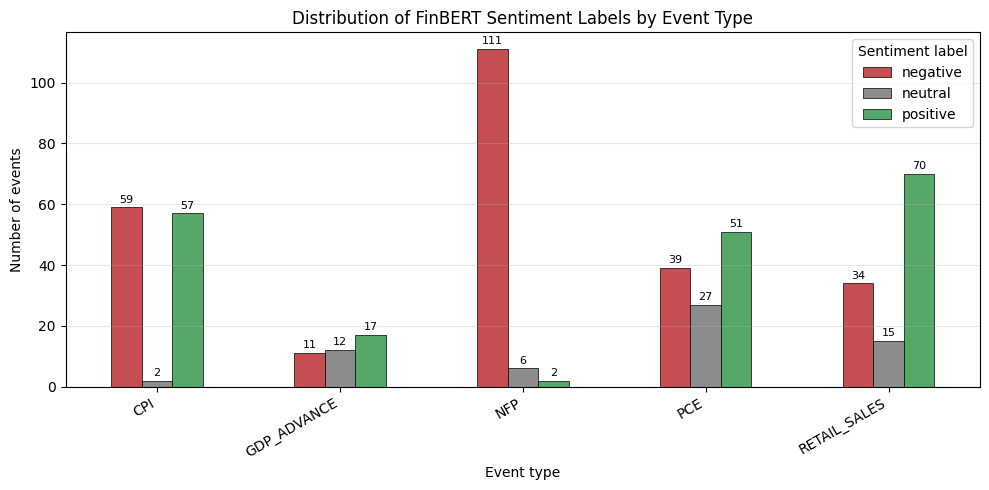

In [ ]:
sentiment_colors = {
    "negative": "#C44E52",   # red
    "neutral": "#8C8C8C",    # grey
    "positive": "#55A868"    # green
}

bar_colors = []

for column in sentiment_by_event.columns:
    bar_colors.append(sentiment_colors[column])


ax = sentiment_by_event.plot(
    kind="bar",
    figsize=(10, 5),
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5
)

for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=8,
        padding=2
    )


plt.title("Distribution of FinBERT Sentiment Labels by Event Type")
plt.xlabel("Event type")
plt.ylabel("Number of events")

plt.xticks(rotation=30, ha="right")

plt.grid(axis="y", alpha=0.3)
plt.legend(title="Sentiment label")

plt.tight_layout()
plt.show()

In [ ]:
avg_return_by_sentiment_pct = events_sentiment.groupby("finbert_sentiment_label")["post_event_30min_return_pct"].mean()

print("\nAverage post-event 30-minute return percentage by FinBERT sentiment:")
print(avg_return_by_sentiment_pct)


Average post-event 30-minute return percentage by FinBERT sentiment:
finbert_sentiment_label
negative    0.018077
neutral     0.025119
positive   -0.004059
Name: post_event_30min_return_pct, dtype: float64


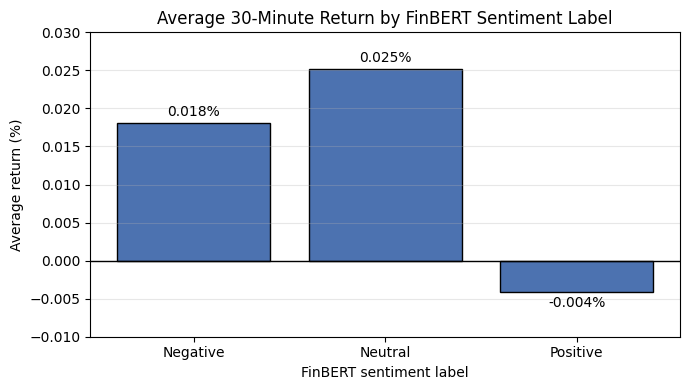

In [ ]:
avg_return_plot = avg_return_by_sentiment_pct.copy()
avg_return_plot.index = avg_return_plot.index.str.lower()
avg_return_plot = avg_return_plot.loc[["negative", "neutral", "positive"]]

plt.figure(figsize=(7, 4))

bars = plt.bar(
    ["Negative", "Neutral", "Positive"],
    avg_return_plot.values,
    color="#4C72B0",
    edgecolor="black"
)

plt.axhline(0, color="black", linewidth=1)

plt.bar_label(
    bars,
    labels=[str(round(x, 3)) + "%" for x in avg_return_plot.values],
    padding=3
)

plt.title("Average 30-Minute Return by FinBERT Sentiment Label")
plt.xlabel("FinBERT sentiment label")
plt.ylabel("Average return (%)")

plt.ylim(-0.01, 0.03)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

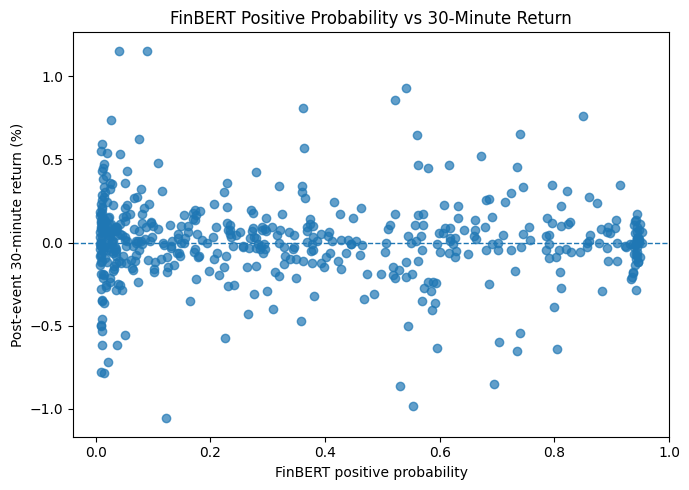

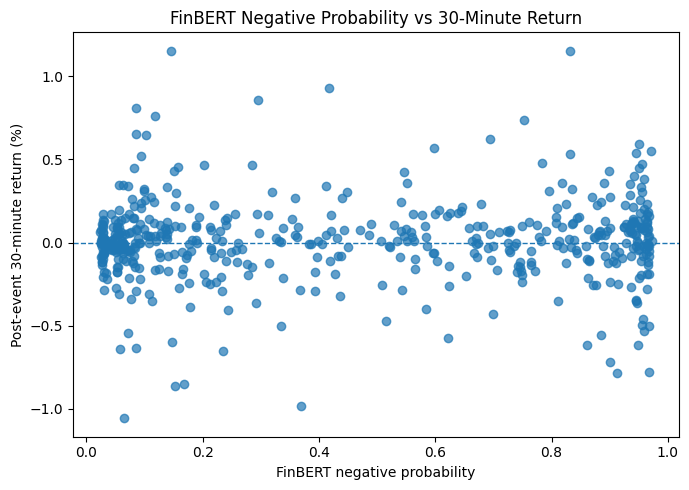

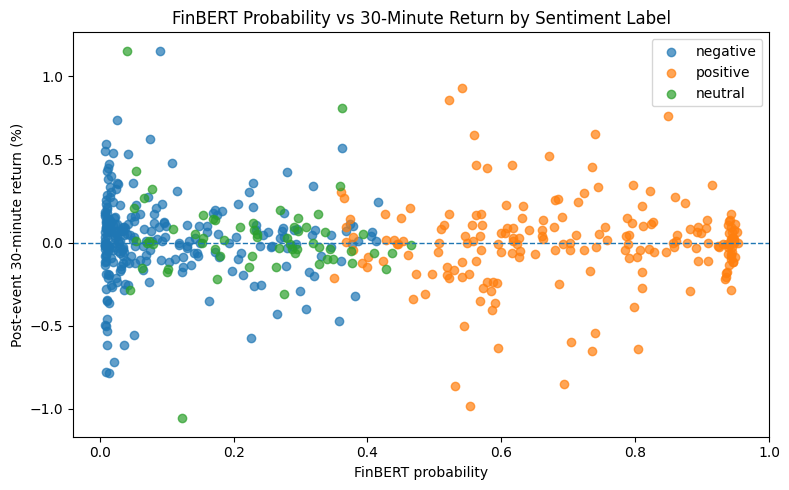

In [ ]:
# scatter plots between FinBERT sentiment probabilities and post-event return

return_column = "post_event_30min_return_pct"

plt.figure(figsize=(7, 5))

plt.scatter(
    events_sentiment["finbert_positive_prob"],
    events_sentiment[return_column],
    alpha=0.7
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("FinBERT Positive Probability vs 30-Minute Return")
plt.xlabel("FinBERT positive probability")
plt.ylabel("Post-event 30-minute return (%)")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))

plt.scatter(
    events_sentiment["finbert_negative_prob"],
    events_sentiment[return_column],
    alpha=0.7
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("FinBERT Negative Probability vs 30-Minute Return")
plt.xlabel("FinBERT negative probability")
plt.ylabel("Post-event 30-minute return (%)")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

labels = events_sentiment["finbert_sentiment_label"].unique()

for label in labels:
    subset = events_sentiment[events_sentiment["finbert_sentiment_label"] == label]

    plt.scatter(
        subset["finbert_positive_prob"],
        subset[return_column],
        alpha=0.7,
        label=label
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("FinBERT Probability vs 30-Minute Return by Sentiment Label")
plt.xlabel("FinBERT positive probability")
plt.ylabel("Post-event 30-minute return (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
finbert = AutoModel.from_pretrained(model_name)

finbert = finbert.to(device)
finbert.eval()

print("\nLoaded:", model_name)
print("Device:", device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Loaded: ProsusAI/finbert
Device: cuda


In [ ]:
embeddings_file = features_folder / "finbert_cls_embeddings.npy"
embedding_ids_file = features_folder / "embedding_event_ids.csv"

force_recompute_embeddings = True

if embeddings_file.exists() and embedding_ids_file.exists() and force_recompute_embeddings == False:
    print("\nEmbeddings already exist. Loading them.")
    finbert_embeddings = np.load(embeddings_file)
    embedding_ids = pd.read_csv(embedding_ids_file)

else:
    batch_size = 8
    max_length = 512

    all_embeddings = []

    for start in range(0, len(texts), batch_size):
        end = start + batch_size
        batch_texts = texts[start:end]

        tokens = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        tokens = {key: value.to(device) for key, value in tokens.items()}

        with torch.no_grad():
            output = finbert(**tokens)

        # CLS token embedding = one 768-dimensional vector for each text
        batch_embeddings = output.last_hidden_state[:, 0, :].cpu().numpy()

        all_embeddings.append(batch_embeddings)

        print("Done:", min(end, len(texts)), "/", len(texts))

    finbert_embeddings = np.vstack(all_embeddings)

    np.save(embeddings_file, finbert_embeddings)

    embedding_ids = pd.DataFrame({"event_id": event_ids})
    embedding_ids.to_csv(embedding_ids_file, index=False)

    print("\nSaved embeddings.")

print("\nEmbedding shape:", finbert_embeddings.shape)

Done: 8 / 513
Done: 16 / 513
Done: 24 / 513
Done: 32 / 513
Done: 40 / 513
Done: 48 / 513
Done: 56 / 513
Done: 64 / 513
Done: 72 / 513
Done: 80 / 513
Done: 88 / 513
Done: 96 / 513
Done: 104 / 513
Done: 112 / 513
Done: 120 / 513
Done: 128 / 513
Done: 136 / 513
Done: 144 / 513
Done: 152 / 513
Done: 160 / 513
Done: 168 / 513
Done: 176 / 513
Done: 184 / 513
Done: 192 / 513
Done: 200 / 513
Done: 208 / 513
Done: 216 / 513
Done: 224 / 513
Done: 232 / 513
Done: 240 / 513
Done: 248 / 513
Done: 256 / 513
Done: 264 / 513
Done: 272 / 513
Done: 280 / 513
Done: 288 / 513
Done: 296 / 513
Done: 304 / 513
Done: 312 / 513
Done: 320 / 513
Done: 328 / 513
Done: 336 / 513
Done: 344 / 513
Done: 352 / 513
Done: 360 / 513
Done: 368 / 513
Done: 376 / 513
Done: 384 / 513
Done: 392 / 513
Done: 400 / 513
Done: 408 / 513
Done: 416 / 513
Done: 424 / 513
Done: 432 / 513
Done: 440 / 513
Done: 448 / 513
Done: 456 / 513
Done: 464 / 513
Done: 472 / 513
Done: 480 / 513
Done: 488 / 513
Done: 496 / 513
Done: 504 / 513
Done:

In [ ]:
embedding_ids = pd.read_csv(embedding_ids_file)

same_order = list(embedding_ids["event_id"]) == list(events["event_id"])

print("\nEmbedding IDs match events:", same_order)
print("Embedding shape:", finbert_embeddings.shape)


Embedding IDs match events: True
Embedding shape: (513, 768)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# target
y = events["label_binary"].astype(int)

# dates for chronological split
events["release_year"] = events["release_datetime_et"].dt.year

print("\nYears:")
print(events["release_year"].value_counts().sort_index())

print("\nTarget counts:")
print(y.value_counts())


Years:
release_year
2016    52
2017    52
2018    52
2019    51
2020    52
2021    52
2022    52
2023    52
2024    52
2025    46
Name: count, dtype: int64

Target counts:
label_binary
1    268
0    245
Name: count, dtype: int64
